<a href="https://colab.research.google.com/github/Poojalakshmi271/AGENTIC-AI/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn sentence-transformers -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv("data.csv")
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [ ]:
df.isnull().sum()
df.describe()

,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,Net sales decreased to EUR 220.5 mn from EUR 4...,neutral
freq,2,3130


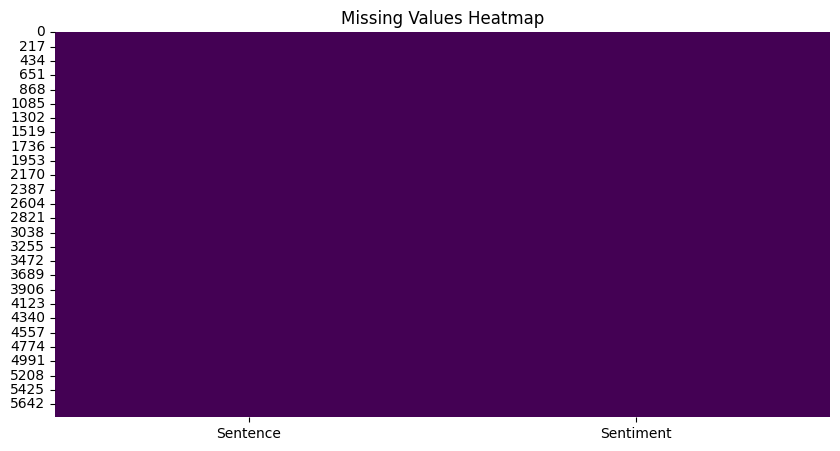

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [ ]:
for col in df.columns:

    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("Missing Values Filled")

Missing Values Filled


/tmp/ipykernel_1816/592430556.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df['clean_text'] = df['Sentence'].apply(clean_text)

In [ ]:
df[['Sentence', 'clean_text']].head()

,Sentence,clean_text
0,The GeoSolutions technology will leverage Bene...,geosolutions technology leverage benefon gps s...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",esi lows bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sales doubled eurm...
3,According to the Finnish-Russian Chamber of Co...,according finnishrussian chamber commerce majo...
4,The Swedish buyout firm has sold its remaining...,swedish buyout firm sold remaining percent sta...


In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,geosolutions technology leverage benefon gps s...,"[geosolutions, technology, leverage, benefon, ..."
1,esi lows bk real possibility,"[esi, lows, bk, real, possibility]"
2,last quarter componenta net sales doubled eurm...,"[last, quarter, componenta, net, sales, double..."
3,according finnishrussian chamber commerce majo...,"[according, finnishrussian, chamber, commerce,..."
4,swedish buyout firm sold remaining percent sta...,"[swedish, buyout, firm, sold, remaining, perce..."


In [ ]:
le = LabelEncoder()

df['Sentiment'] = le.fit_transform(df['Sentiment'])

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

print(X_tfidf.shape)

(5836, 5000)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

print(X.shape)

(5836, 5000)
